In [1]:
# %% [markdown]
# # DBFSNet Training & Evaluation Visualizer
# This notebook generates training history curves and validation metrics (ROC, Confusion Matrix) 
# using a clean, publication-ready white style.

# %%
import sys
import os
import csv
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)

# Set path to project root
PROJECT_ROOT = Path("C:/Users/sanid/Desktop/riddhi")
sys.path.insert(0, str(PROJECT_ROOT))

# Import your model and dataset modules
from src.dataset import get_dataloaders
from src.model   import DBFSNet

# Apply a clean white theme globally
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'grid.color': '#eeeeee',
    'font.family': 'sans-serif',
    'font.size': 10
})

print("✅ Setup complete. Theme set to clean white.")

c:\Users\sanid\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup complete. Theme set to clean white.


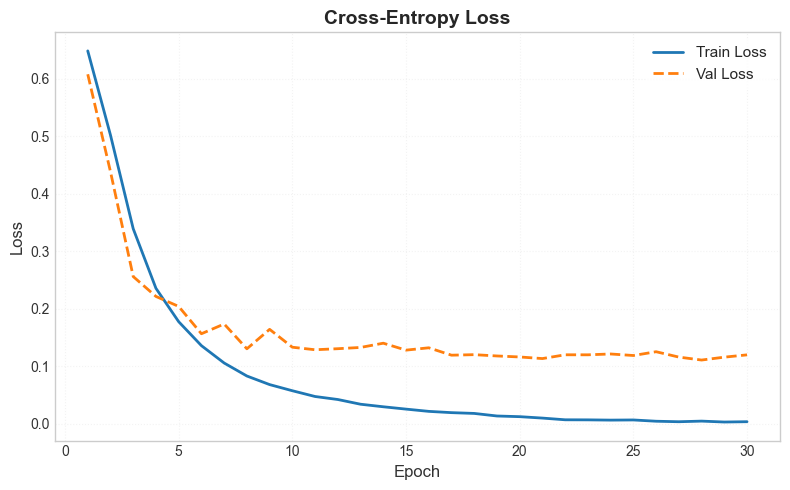

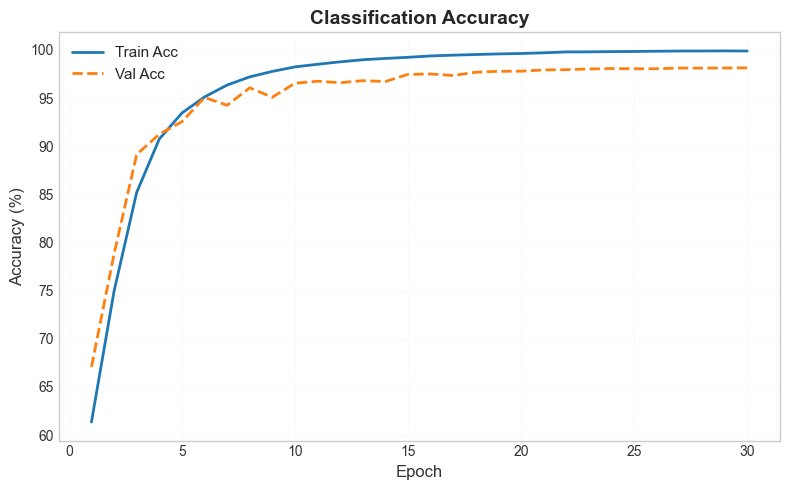

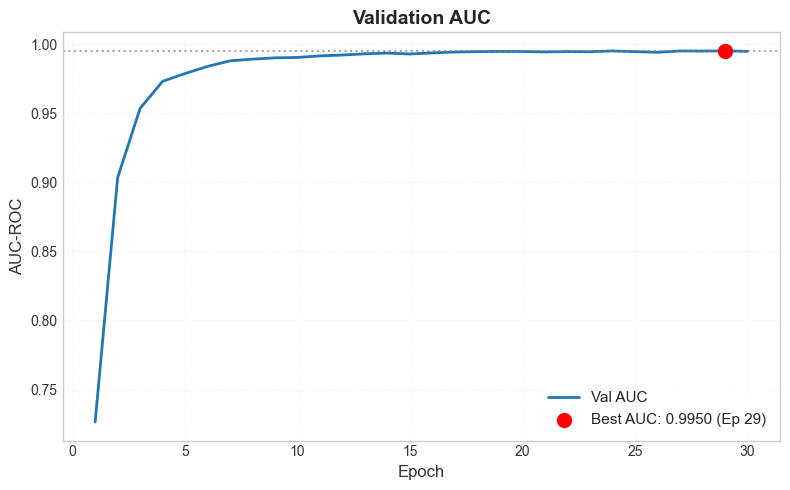

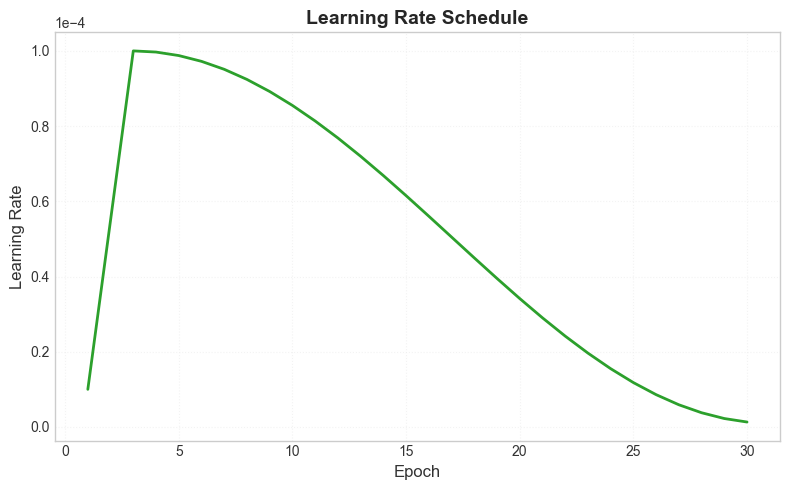

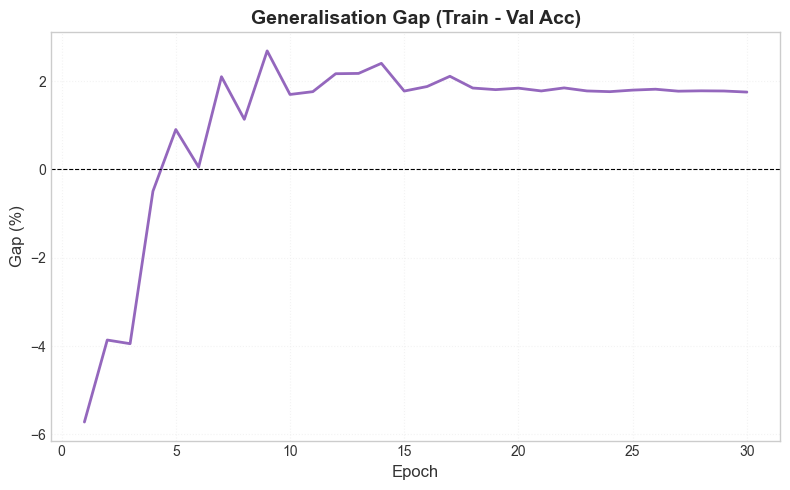

C:\Users\sanid\AppData\Local\Temp\ipykernel_10396\240061369.py:138: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\sanid\AppData\Local\Temp\ipykernel_10396\240061369.py:139: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(output_dir / "training_summary.png", dpi=200, facecolor='white', bbox_inches="tight")
C:\Users\sanid\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


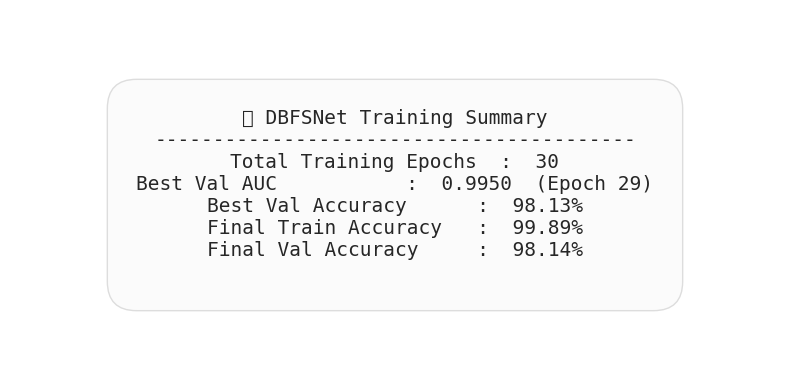

✅ All 6 metrics saved as individual images in: C:\Users\sanid\Desktop\riddhi\outputs


In [5]:
# %%
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_training_metrics_individual(csv_path, output_dir):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"Metrics CSV not found at {csv_path}. Did you run training first?")
        
    # Read metrics
    d = {"epoch":[], "train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[], "val_auc":[], "lr":[]}
    with open(csv_path, newline="") as f:
        for row in csv.DictReader(f):
            d["epoch"].append(int(row["epoch"]))
            d["train_loss"].append(float(row["train_loss"]))
            d["train_acc"].append(float(row["train_acc"]))
            d["val_loss"].append(float(row["val_loss"]))
            d["val_acc"].append(float(row["val_acc"]))
            d["val_auc"].append(float(row["val_auc"]))
            d["lr"].append(float(row["lr"]))

    epochs = d["epoch"]
    n_epochs = len(epochs)
    best_idx = np.argmax(d["val_auc"])
    best_epoch = epochs[best_idx]
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Palette definition
    c_train = "#1f77b4" # Deep Blue
    c_val = "#ff7f0e"   # Warm Orange
    c_gap = "#9467bd"   # Soft Purple
    c_lr = "#2ca02c"    # Green
    
    # Set default figure settings for individual plots
    figsize = (8, 5)
    
    # ---------------------------------------------------------
    # 1. Train vs Val Loss
    # ---------------------------------------------------------
    plt.figure(figsize=figsize, facecolor='white')
    plt.plot(epochs, d["train_loss"], label="Train Loss", color=c_train, lw=2)
    plt.plot(epochs, d["val_loss"], label="Val Loss", color=c_val, lw=2, linestyle='--')
    plt.title("Cross-Entropy Loss", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.savefig(output_dir / "loss_curve.png", dpi=200, facecolor='white', bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 2. Train vs Val Accuracy
    # ---------------------------------------------------------
    plt.figure(figsize=figsize, facecolor='white')
    plt.plot(epochs, [a * 100 for a in d["train_acc"]], label="Train Acc", color=c_train, lw=2)
    plt.plot(epochs, [a * 100 for a in d["val_acc"]], label="Val Acc", color=c_val, lw=2, linestyle='--')
    plt.title("Classification Accuracy", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.savefig(output_dir / "accuracy_curve.png", dpi=200, facecolor='white', bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 3. Validation AUC
    # ---------------------------------------------------------
    plt.figure(figsize=figsize, facecolor='white')
    plt.plot(epochs, d["val_auc"], label="Val AUC", color=c_train, lw=2)
    plt.axhline(y=d["val_auc"][best_idx], color='gray', linestyle=':', alpha=0.7)
    plt.scatter(best_epoch, d["val_auc"][best_idx], color="red", s=100, zorder=5, 
                label=f"Best AUC: {d['val_auc'][best_idx]:.4f} (Ep {best_epoch})")
    plt.title("Validation AUC", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("AUC-ROC", fontsize=12)
    plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.savefig(output_dir / "auc_curve.png", dpi=200, facecolor='white', bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 4. Learning Rate Schedule
    # ---------------------------------------------------------
    plt.figure(figsize=figsize, facecolor='white')
    plt.plot(epochs, d["lr"], color=c_lr, lw=2)
    plt.title("Learning Rate Schedule", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Learning Rate", fontsize=12)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.savefig(output_dir / "learning_rate_curve.png", dpi=200, facecolor='white', bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 5. Generalisation Gap
    # ---------------------------------------------------------
    plt.figure(figsize=figsize, facecolor='white')
    gap = np.array(d["train_acc"]) - np.array(d["val_acc"])
    plt.plot(epochs, gap * 100, color=c_gap, lw=2)
    plt.axhline(0, color="black", lw=0.8, ls="--")
    plt.title("Generalisation Gap (Train - Val Acc)", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Gap (%)", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.savefig(output_dir / "generalization_gap.png", dpi=200, facecolor='white', bbox_inches="tight")
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 6. Summary Metrics Block (Rendered as text graphic)
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 4), facecolor='white')
    plt.axis('off')
    summary_text = (
        f"📊 DBFSNet Training Summary\n"
        f"-----------------------------------------\n"
        f"Total Training Epochs  :  {n_epochs}\n"
        f"Best Val AUC           :  {d['val_auc'][best_idx]:.4f}  (Epoch {best_epoch})\n"
        f"Best Val Accuracy      :  {d['val_acc'][best_idx]*100:.2f}%\n"
        f"Final Train Accuracy   :  {d['train_acc'][-1]*100:.2f}%\n"
        f"Final Val Accuracy     :  {d['val_acc'][-1]*100:.2f}%\n"
    )
    plt.text(0.5, 0.5, summary_text, fontsize=14, family='monospace', 
             va='center', ha='center', bbox=dict(boxstyle="round,pad=1.5", facecolor='#fbfbfb', edgecolor='#dddddd'))
    plt.tight_layout()
    plt.savefig(output_dir / "training_summary.png", dpi=200, facecolor='white', bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"✅ All 6 metrics saved as individual images in: {output_dir}")

# Execute plot generation
# Make sure PROJECT_ROOT is defined earlier in your notebook
metrics_csv = PROJECT_ROOT / "checkpoints" / "training_metrics.csv"
output_folder = PROJECT_ROOT / "outputs"
plot_training_metrics_individual(metrics_csv, output_folder)

In [3]:
# %%
# Load Configuration File
config_path = PROJECT_ROOT / "configs" / "config.yaml"
with open(config_path) as f:
    cfg = yaml.safe_load(f)

# Hardcode correct paths for notebook environment
cfg["paths"]["checkpoint_dir"] = str(PROJECT_ROOT / "checkpoints")
cfg["paths"]["output_dir"]     = str(PROJECT_ROOT / "outputs")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Initialize DBFSNet Model
model = DBFSNet(cfg).to(device)

# 2. Load Checkpoint (Change to "latest.pth" or "best.pth" as needed)
ckpt_path = Path(cfg["paths"]["checkpoint_dir"]) / "best.pth"
if not ckpt_path.exists():
    ckpt_path = Path(cfg["paths"]["checkpoint_dir"]) / "latest.pth"

checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model"])
print(f"Loaded weight state from: {ckpt_path}")

# 3. Load Validation Data Split
_, val_loader = get_dataloaders(cfg)

# 4. Generate Predictions
model.eval()
all_probs, all_labels, all_gates = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Running Inference"):
        imgs = imgs.to(device)
        logits, gates = model(imgs)
        
        all_probs.extend(torch.sigmoid(logits.squeeze(1)).cpu().tolist())
        all_labels.extend(labels.tolist())
        all_gates.extend(gates.squeeze(1).cpu().tolist())

probs  = np.array(all_probs)
labels = np.array(all_labels)
gates  = np.array(all_gates)
preds  = (probs > 0.5).astype(int)

# Print raw evaluation summary
print("\n--- Model Predictions Extracted ---")
print(f"Validation Target Size: {len(labels)}")
print(f"Mean Spatial Gate Activation: {gates.mean():.4f}")

Using device: cpu
Loaded weight state from: C:\Users\sanid\Desktop\riddhi\checkpoints\best.pth
[FFDataset] train: 74080 samples  (12036 real [16.2%], 62044 fake [83.8%])
[FFDataset] val  : 18521 samples  (2963 real [16.0%], 15558 fake [84.0%])
[FFDataset] Balanced sampler:
  Real  count= 12036  weight=0.000083
  Fake  count= 62044  weight=0.000016
  → ~50% real / ~50% fake per batch


Running Inference:   0%|          | 0/1158 [00:00<?, ?it/s]

torch.Size([16, 9, 224, 224])


Running Inference:   0%|          | 1/1158 [00:03<1:13:41,  3.82s/it]

torch.Size([16, 9, 224, 224])


...

torch.Size([16, 9, 224, 224])


Running Inference: 100%|█████████▉| 1157/1158 [55:08<00:03,  3.22s/it]

torch.Size([9, 9, 224, 224])


Running Inference: 100%|██████████| 1158/1158 [55:10<00:00,  2.86s/it]


--- Model Predictions Extracted ---
Validation Target Size: 18521
Mean Spatial Gate Activation: 1.0000


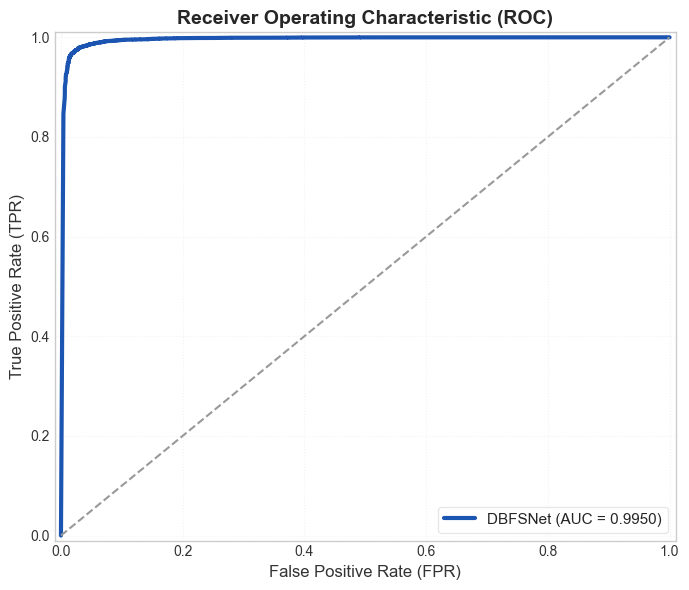

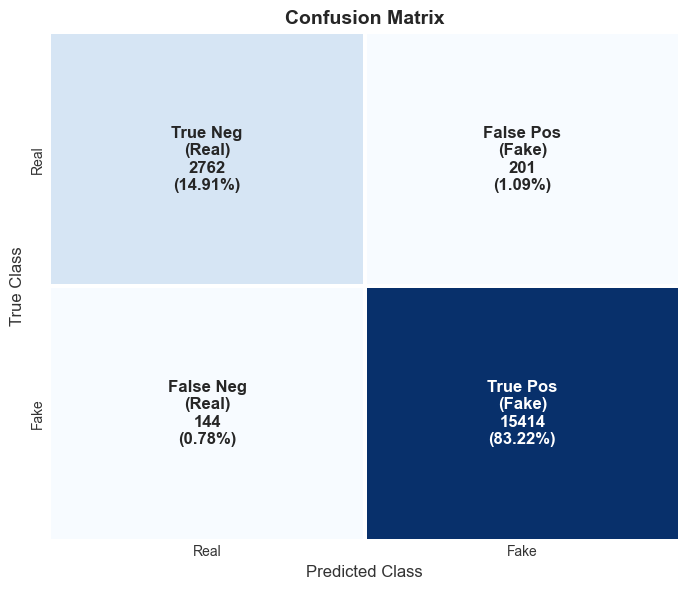

✅ Saved ROC Curve to: C:\Users\sanid\Desktop\riddhi\outputs\roc_curve_white.png
✅ Saved Confusion Matrix to: C:\Users\sanid\Desktop\riddhi\outputs\confusion_matrix_white.png

             CLASSIFICATION METRICS REPORT
Accuracy : 98.14%
AUC Score: 0.9950
-------------------------------------------------------
              precision    recall  f1-score   support

        Real       0.95      0.93      0.94      2963
        Fake       0.99      0.99      0.99     15558

    accuracy                           0.98     18521
   macro avg       0.97      0.96      0.97     18521
weighted avg       0.98      0.98      0.98     18521



In [6]:
# %%
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Ensure output directory exists
val_out_dir = Path(cfg["paths"]["output_dir"])
val_out_dir.mkdir(parents=True, exist_ok=True)

# Common figure size for consistency
figsize = (7, 6)

# ---------------------------------------------------------
# 1. Receiver Operating Characteristic (ROC) Curve
# ---------------------------------------------------------
plt.figure(figsize=figsize, facecolor='white')

fpr, tpr, _ = roc_curve(labels, probs)
auc_val = roc_auc_score(labels, probs)

plt.plot(fpr, tpr, label=f"DBFSNet (AUC = {auc_val:.4f})", color="#1c54b2", lw=3)
plt.plot([0, 1], [0, 1], color="#999999", lw=1.5, linestyle="--") # Chance line
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.title("Receiver Operating Characteristic (ROC)", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", frameon=True, facecolor='white', edgecolor='#e2e2e2', fontsize=11)
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()

# Save ROC curve
roc_path = val_out_dir / "roc_curve_white.png"
plt.savefig(roc_path, dpi=200, facecolor='white', bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------
# 2. Confusion Matrix
# ---------------------------------------------------------
plt.figure(figsize=figsize, facecolor='white')

cm = confusion_matrix(labels, preds)
group_names = ['True Neg\n(Real)', 'False Pos\n(Fake)', 'False Neg\n(Real)', 'True Pos\n(Fake)']
group_counts = [f"{value:d}" for value in cm.flatten()]
group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]

labels_grid = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels_grid = np.asarray(labels_grid).reshape(2, 2)

# Use a clean Light-Blue Sequential colormap (Blues)
sns.heatmap(cm, annot=labels_grid, fmt="", cmap="Blues", cbar=False,
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={"fontsize":12, "fontweight":"bold"}, linewidths=1.5, linecolor='white')

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()

# Save Confusion Matrix
cm_path = val_out_dir / "confusion_matrix_white.png"
plt.savefig(cm_path, dpi=200, facecolor='white', bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------
# 3. Console Classification Report
# ---------------------------------------------------------
print(f"✅ Saved ROC Curve to: {roc_path}")
print(f"✅ Saved Confusion Matrix to: {cm_path}\n")

print("="*55)
print("             CLASSIFICATION METRICS REPORT")
print("="*55)
print(f"Accuracy : {accuracy_score(labels, preds)*100:.2f}%")
print(f"AUC Score: {auc_val:.4f}")
print("-"*55)
print(classification_report(labels, preds, target_names=['Real', 'Fake']))
print("="*55)